# Final Project of the Data Science Diploma Program at Instituto Artek
By Enrique Olvera Monroy

---

# Proyecto Final del Diplomado en Data Science del Instituto Artek
Por Enrique Olvera Monroy

## Football Player Rating Prediction using Regression Models

---

## Predicción de la Calificación de Jugadores de Fútbol mediante Modelos de Regresión

This project was developed as the final assignment for the Data Science Diploma Program at Instituto Artek. It demonstrates a practical implementation of a Decision Tree Regression model using real-world data to predict the overall rating of football players based on their physical and technical attributes.

---

Este proyecto fue desarrollado como el trabajo final del Diplomado en Data Science del Instituto Artek. Demuestra una implementación práctica de un modelo de Regresión de Árbol de Decisión, utilizando datos reales para predecir la calificación general de jugadores de fútbol con base en sus atributos físicos y técnicos.

### Data

---

### Datos

The dataset comes from Kaggle's Soccer Player Dataset and contains:

11,060 rows
25 features (after preprocessing)
Data cleaning, feature engineering (like computing Age), and encoding of categorical variables were performed.

https://www.kaggle.com/datasets/hugomathien/soccer

---

El conjunto de datos proviene del Soccer Player Dataset de Kaggle y contiene:

11,060 filas
25 características (después del preprocesamiento)
Se realizó limpieza de datos, ingeniería de características (como el cálculo de la Edad) y codificación de variables categóricas.

https://www.kaggle.com/datasets/hugomathien/soccer

To begin the project, it was necessary to access and extract relevant data from a structured relational database. This was accomplished using a SQL query that joined two key tables: Player and Player_Attributes.

The query performs the following tasks:

Selects distinct player records to avoid duplicates.

Joins the Player table with the Player_Attributes table using the player ID as the common key.

Extracts essential information such as personal details (e.g., name, birthday, height, weight), player preferences (e.g., preferred foot, work rates), and a comprehensive set of technical and physical performance attributes (e.g., passing, dribbling, stamina, aggression, overall rating).

---

Para comenzar el proyecto, fue necesario acceder y extraer datos relevantes de una base de datos relacional estructurada. Esto se logró mediante una consulta SQL que unió dos tablas clave: Player y Player_Attributes.

La consulta realiza las siguientes tareas:

Selecciona registros de jugadores distintos para evitar duplicados.

Une la tabla Player con la tabla Player_Attributes utilizando el ID del jugador como clave común.

Extrae información esencial como datos personales (por ejemplo, nombre, fecha de nacimiento, estatura, peso), preferencias del jugador (por ejemplo, pie preferido, ritmos de trabajo) y un conjunto completo de atributos técnicos y físicos de desempeño (por ejemplo, pases, regate, resistencia, agresividad, calificación general).

### Libraries
These libraries collectively enabled a complete machine learning pipeline, from data preparation to model training and performance evaluation.

---

### Librerías
Estas librerías, en conjunto, permitieron construir un flujo completo de machine learning, desde la preparación de los datos hasta el entrenamiento del modelo y la evaluación del desempeño.

In [1]:
# Import required libraries / Importar las librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, max_error
from sklearn import tree

### Preprocessing data

---

### Preprocesamiento de datos

In [2]:
# Creating a Data Frame / Creando un Data Frame

df = pd.read_excel("data/Players_Attributes.xlsx")
pd.options.display.max_columns = None
df.head()

,player_name,birthday,height,weight,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,heading_accuracy,short_passing,dribbling,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,aggression,penalties,overall_rating
0,Aaron Appindangoye,1992-02-29,182.88,187,71.0,right,medium,medium,49.0,71.0,61.0,51.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,71.0,48.0,67.0
1,Aaron Cresswell,1989-12-15,170.18,146,71.0,right,medium,medium,49.0,71.0,61.0,51.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,71.0,48.0,67.0
2,Aaron Doran,1991-05-13,170.18,163,66.0,right,medium,medium,49.0,71.0,61.0,51.0,49.0,60.0,64.0,59.0,47.0,65.0,55.0,58.0,54.0,76.0,63.0,48.0,62.0
3,Aaron Galindo,1982-05-08,182.88,198,65.0,right,medium,medium,48.0,70.0,60.0,50.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,62.0,47.0,61.0
4,Aaron Hughes,1979-11-08,182.88,154,65.0,right,medium,medium,48.0,70.0,60.0,50.0,48.0,60.0,64.0,59.0,46.0,65.0,54.0,58.0,54.0,76.0,62.0,47.0,61.0


In [3]:
# Overview of the dataset: 25 columns, ~11,000 entries. Mixed data types with some missing values.
# Descripción general del dataset: 25 columnas, ~11,000 registros. Tipos de datos mixtos con algunos valores faltantes.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11060 entries, 0 to 11059
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   player_name          11060 non-null  str           
 1   birthday             11060 non-null  datetime64[us]
 2   height               11060 non-null  float64       
 3   weight               11060 non-null  int64         
 4   potential            11021 non-null  float64       
 5   preferred_foot       11021 non-null  str           
 6   attacking_work_rate  10753 non-null  str           
 7   defensive_work_rate  11021 non-null  object        
 8   crossing             11021 non-null  float64       
 9   heading_accuracy     11021 non-null  float64       
 10  short_passing        11021 non-null  float64       
 11  dribbling            11021 non-null  float64       
 12  ball_control         11021 non-null  float64       
 13  acceleration         11021 non-null  float

In [4]:
# Checking for missing values in each column.
# Revisando valores faltantes en cada columna.

df.isna().sum()

player_name              0
birthday                 0
height                   0
weight                   0
potential               39
preferred_foot          39
attacking_work_rate    307
defensive_work_rate     39
crossing                39
heading_accuracy        39
short_passing           39
dribbling               39
ball_control            39
acceleration            39
sprint_speed            39
agility                125
reactions               39
balance                125
shot_power              39
jumping                125
stamina                 39
strength                39
aggression              39
penalties               39
overall_rating          39
dtype: int64

Most columns have 39 missing values, but 'attacking_work_rate', 'agility', 'balance', and 'jumping' have more.

---

La mayoría de las columnas tienen 39 valores faltantes, pero 'attacking_work_rate', 'agility', 'balance' y 'jumping' tienen más.

In [5]:
# Create a new column 'age' based on the 'birthday' column
# Crear una nueva columna 'age' a partir de la columna 'birthday'
df["birthday"] = pd.to_datetime(df["birthday"])

In [6]:
# Extract the player's birth year to calculate their age
# Extraer el año de nacimiento del jugador para calcular su edad
años = []

for i in range(df.shape[0]):
  year = df["birthday"][i].year
  años.append(year)

df["Only_Year"] = años
df["Age"] = 2022 - df["Only_Year"]

In [7]:
# Rearranging columns
# Reordenando columnas
df = df.drop(['birthday', 'Only_Year'], axis=1)

second_column = df.pop('Age') 
df.insert(1, 'Age', second_column)

In [8]:
# Checking unwanted values from categorical columns
# Revisando valores no deseados en las columnas categóricas

print(df["attacking_work_rate"].unique())
print(df["preferred_foot"].unique())
print(df["defensive_work_rate"].unique())

<StringArray>
['medium', 'high', nan, 'low', 'le', 'norm']
Length: 6, dtype: str
<StringArray>
['right', 'left', nan]
Length: 3, dtype: str
['medium' 'high' 'low' '_0' nan 5 'ean' 'o' 1 'ormal' 7 2 8]


In [9]:
print(df["attacking_work_rate"].value_counts())
print(df["preferred_foot"].value_counts())
print(df["defensive_work_rate"].value_counts())

attacking_work_rate
medium    7520
high      2793
low        406
norm        22
le          12
Name: count, dtype: int64
preferred_foot
right    8528
left     2493
Name: count, dtype: int64
defensive_work_rate
medium    8046
high      1452
low       1218
_0         124
o           58
1           46
ormal       22
5           20
8           13
ean         12
2            6
7            4
Name: count, dtype: int64


In [10]:
# Convert strange or invalid values to NaN to allow imputation later
# Convertir valores extraños o inválidos en NaN para permitir su imputación más adelante

df = df.replace(['None', 'le' ,'norm', '_0','5' ,'ean' ,'o', '1' ,'ormal', '7', '2' ,'8',1,5,8,2,7], np.nan)

In [11]:
# Confirmation of no strange or invalid values
# Confirmación de que ya no hay valores extraños o inválidos

print(df["attacking_work_rate"].unique())
print(df["preferred_foot"].unique())
print(df["defensive_work_rate"].unique())

<StringArray>
['medium', 'high', nan, 'low']
Length: 4, dtype: str
<StringArray>
['right', 'left', nan]
Length: 3, dtype: str
['medium' 'high' 'low' nan]


In [12]:
# Checking Null Values
# Revisando valores nulos

df.isnull().sum()

player_name              0
Age                      0
height                   0
weight                   0
potential               39
preferred_foot          39
attacking_work_rate    341
defensive_work_rate    344
crossing                51
heading_accuracy        46
short_passing           41
dribbling               51
ball_control            39
acceleration            39
sprint_speed            39
agility                125
reactions               39
balance                125
shot_power              39
jumping                125
stamina                 39
strength                39
aggression              39
penalties               43
overall_rating          39
dtype: int64

### Split variables into X (features) and Y (target)

---

### Dividir las variables en X (características) e Y (objetivo)

In [13]:
X = df.iloc[:,1:24].values
y = df.iloc[:,-1:].values

In [14]:
# Visualize X variables (features)
# Visualizar las variables X (características)
X[0]

array([30, 182.88, 187, 71.0, 'right', 'medium', 'medium', 49.0, 71.0,
       61.0, 51.0, 49.0, 60.0, 64.0, 59.0, 47.0, 65.0, 55.0, 58.0, 54.0,
       76.0, 71.0, 48.0], dtype=object)

In [15]:
# Visualize y variable (target)
# Visualizar la variable y (objetivo)
y[0]

array([67.])

### Impute missing values

---

### Imputar valores faltantes

In [16]:
# Checking for missing values in each column.
# Revisando valores faltantes en cada columna.

x_sinNAN = pd.DataFrame(X)
x_sinNAN.isna().sum()

0       0
1       0
2       0
3      39
4      39
5     341
6     344
7      51
8      46
9      41
10     51
11     39
12     39
13     39
14    125
15     39
16    125
17     39
18    125
19     39
20     39
21     39
22     43
dtype: int64

In [17]:
# Impute missing values in categorical variables using the 'most_frequent' strategy.
# This replaces missing values with the most common value in each column.
# Most Frequent strategy (3,4,5,6). Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.
# Imputar valores faltantes en variables categóricas usando la estrategia 'most_frequent'.
# Esto reemplaza los valores faltantes con el valor más frecuente de cada columna.
# Estrategia Most Frequent (3,4,5,6). Se puede usar con datos de texto o numéricos. Si hay más de un valor con la misma frecuencia, se regresa el menor.

imputer1 = SimpleImputer(strategy = "most_frequent")
X[:,3:7] = imputer1.fit_transform(X[:,3:7])

In [18]:
x_sinNAN = pd.DataFrame(X)
x_sinNAN.isna().sum()

0       0
1       0
2       0
3       0
4       0
5       0
6       0
7      51
8      46
9      41
10     51
11     39
12     39
13     39
14    125
15     39
16    125
17     39
18    125
19     39
20     39
21     39
22     43
dtype: int64

In [19]:
# Impute missing values in numerical variables using the 'median' strategy. This replaces missing values with the median of each column (numeric data only). 
# (7-22) "median", replace missing values using the median along each column. Can only be used with numeric data.
# Imputar valores faltantes en variables numéricas usando la estrategia 'median'. Esto reemplaza los valores faltantes con la mediana de cada columna (solo datos numéricos).
# (7-22) 'median', reemplaza los valores faltantes usando la mediana de cada columna. Solo se puede usar con datos numéricos.

imputer1 = SimpleImputer(strategy = "median")
X[:,7:23] = imputer1.fit_transform(X[:,7:23])

In [20]:
# No NaN values remaining
# Ya no quedan valores NaN
x_sinNAN = pd.DataFrame(X)
x_sinNAN.isna().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
dtype: int64

#### Impute missing values in variable y

---

#### Imputar valores faltantes en la variable y

In [21]:
# No NaN values remaining
# Ya no quedan valores NaN

y_sinNAN = pd.DataFrame(y)
y_sinNAN.isnull().sum()

0    39
dtype: int64

In [22]:
# Impute missing values in numerical variables using the 'mean' strategy.
# Imputar valores faltantes en variables numéricas usando la estrategia 'mean'.

y = y.copy()


imputer3 = SimpleImputer(strategy = "mean")
y[:,[0]] = imputer3.fit_transform(y[:,[0]]) #Coloqué otro corchete porque se espera un array 2D / Added another bracket because a 2D array is expected

In [23]:
# No NaN values remaining
# Ya no quedan valores NaN

y_sinNAN = pd.DataFrame(y)
y_sinNAN.isnull().sum()

0    0
dtype: int64

### Codification

---

### Codificación

#### Label Encoder

PREFERRED_FOOT (VARIABLE 4)

Label Encoder = 0,1,2,3...

---

#### Label Encoder (Codificador de Etiquetas)

PREFERRED_FOOT (VARIABLE 4)

Label Encoder = 0,1,2,3...

In [24]:
# Visualize the dataset variables
# Visualizar las variables del dataset
X[0]

array([30, 182.88, 187, 71.0, 'right', 'medium', 'medium', 49.0, 71.0,
       61.0, 51.0, 49.0, 60.0, 64.0, 59.0, 47.0, 65.0, 55.0, 58.0, 54.0,
       76.0, 71.0, 48.0], dtype=object)

In [25]:
# Label Encoder

lb = LabelEncoder()
X[:,4] = lb.fit_transform(X[:,4]) #cuarta columna / fourth column

In [26]:
# Check that LabelEncoder was applied correctly. Instead of preferred_foot (left, right) now we have right = 1, left = 0
# Verificar que LabelEncoder se aplicó correctamente. En lugar de preferred_foot (left, right) ahora tenemos right = 1, left = 0

X[0]

array([30, 182.88, 187, 71.0, 1, 'medium', 'medium', 49.0, 71.0, 61.0,
       51.0, 49.0, 60.0, 64.0, 59.0, 47.0, 65.0, 55.0, 58.0, 54.0, 76.0,
       71.0, 48.0], dtype=object)

#### One Hot

VARIABLE (5,6)

One Hot = Create a matrix

0 0 1

0 1 0

1 0 0

---

#### One Hot (Codificación One Hot)

VARIABLE (5,6)

One Hot = Crear una matriz

0 0 1

0 1 0

1 0 0

In [27]:
# One Hot / Codificación One Hot
 
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [5])], remainder = 'passthrough')  # con remainder = 'drop' solo regresa la columna transformada / with remainder = 'drop' it only returns the transformed column
X = np.array(ct.fit_transform(X))

In [28]:
# Check that OneHotEncoder was applied correctly (Step 1)
# Verificar que OneHotEncoder se aplicó correctamente (Paso 1)
X[0]

array([0.0, 0.0, 1.0, 30, 182.88, 187, 71.0, 1, 'medium', 49.0, 71.0,
       61.0, 51.0, 49.0, 60.0, 64.0, 59.0, 47.0, 65.0, 55.0, 58.0, 54.0,
       76.0, 71.0, 48.0], dtype=object)

In [29]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [8])], remainder = 'passthrough')  # con remainder = 'drop' solo regresa la columna transformada / with remainder = 'drop' it only returns the transformed column
X = np.array(ct.fit_transform(X))

In [30]:
# Check that OneHotEncoder was applied correctly (Step 2)
# Verificar que OneHotEncoder se aplicó correctamente (Paso 2)
X[0]

array([0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 30, 182.88, 187, 71.0, 1, 49.0, 71.0,
       61.0, 51.0, 49.0, 60.0, 64.0, 59.0, 47.0, 65.0, 55.0, 58.0, 54.0,
       76.0, 71.0, 48.0], dtype=object)

### Split data into training and test sets

---

### Dividir los datos en conjuntos de entrenamiento y prueba

In [31]:
# Split data into training and test sets 75%, 25%.
# Dividir los datos en conjuntos de entrenamiento y prueba 75%, 25%.

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=1)

### Standarization

---

### Estandarización

In [32]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

### Models

---

### Modelos

#### KNN

In [33]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [34]:
y_pred_knn = knn.predict(X_test)

r2_knn = r2_score(y_test,y_pred_knn)
print("R2 " ,r2_knn)

mse_knn = mean_squared_error(y_test,y_pred_knn)
print("Mean Square Error ",mse_knn)

me_knn = max_error(y_test,y_pred_knn)
print("Max Error ", me_knn)

R2  0.9021676105899709
Mean Square Error  4.824319316508628
Max Error  11.400000000000006


#### Linear Regression

---

#### Regresión Lineal

In [35]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 27)","[[ 0.02, 0.13,-0.11,..., 1.45,-0.06, 0.2 ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[68.51]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,27
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(25)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](27,)","[262.15,157.7 ,123.96,..., 22.03, 0. , 0. ]"


In [36]:
y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test,y_pred_lr)
print("R2 " ,r2_lr)

mse_lr = mean_squared_error(y_test,y_pred_lr)
print("Mean Square Error ",mse_lr)

me_lr = max_error(y_test,y_pred_lr)
print("Max Error ", me_lr)

R2  0.7803626188248693
Mean Square Error  10.830777690501018
Max Error  21.906087005215312


#### Support Vector Regression (SVR)

---

#### Regresión de Vectores de Soporte (SVR)

In [37]:
SVR = SVR(kernel = "linear")
SVR.fit(X_train,y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [38]:
y_pred_MSV = SVR.predict(X_test)

r2_MSV = r2_score(y_test,y_pred_MSV)
print("R2 " ,r2_MSV)

mse_MSV = mean_squared_error(y_test,y_pred_MSV)
print("Mean Square Error ",mse_MSV)

me_MSV = max_error(y_test,y_pred_MSV)
print("Max Error ", me_MSV)

R2  0.779761437684537
Mean Square Error  10.860423187309552
Max Error  22.372785825844005


#### Decision Tree

---

#### Árbol de Decisión

In [39]:
dt = DecisionTreeRegressor(random_state=1)
dt.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [40]:
y_pred_DT = SVR.predict(X_test)

r2_DT = r2_score(y_test,y_pred_DT)
print("R2 " ,r2_DT)

mse_DT = mean_squared_error(y_test,y_pred_DT)
print("Mean Square Error ",mse_DT)

me_DT = max_error(y_test,y_pred_DT)
print("Max Error ", me_DT)

R2  0.779761437684537
Mean Square Error  10.860423187309552
Max Error  22.372785825844005


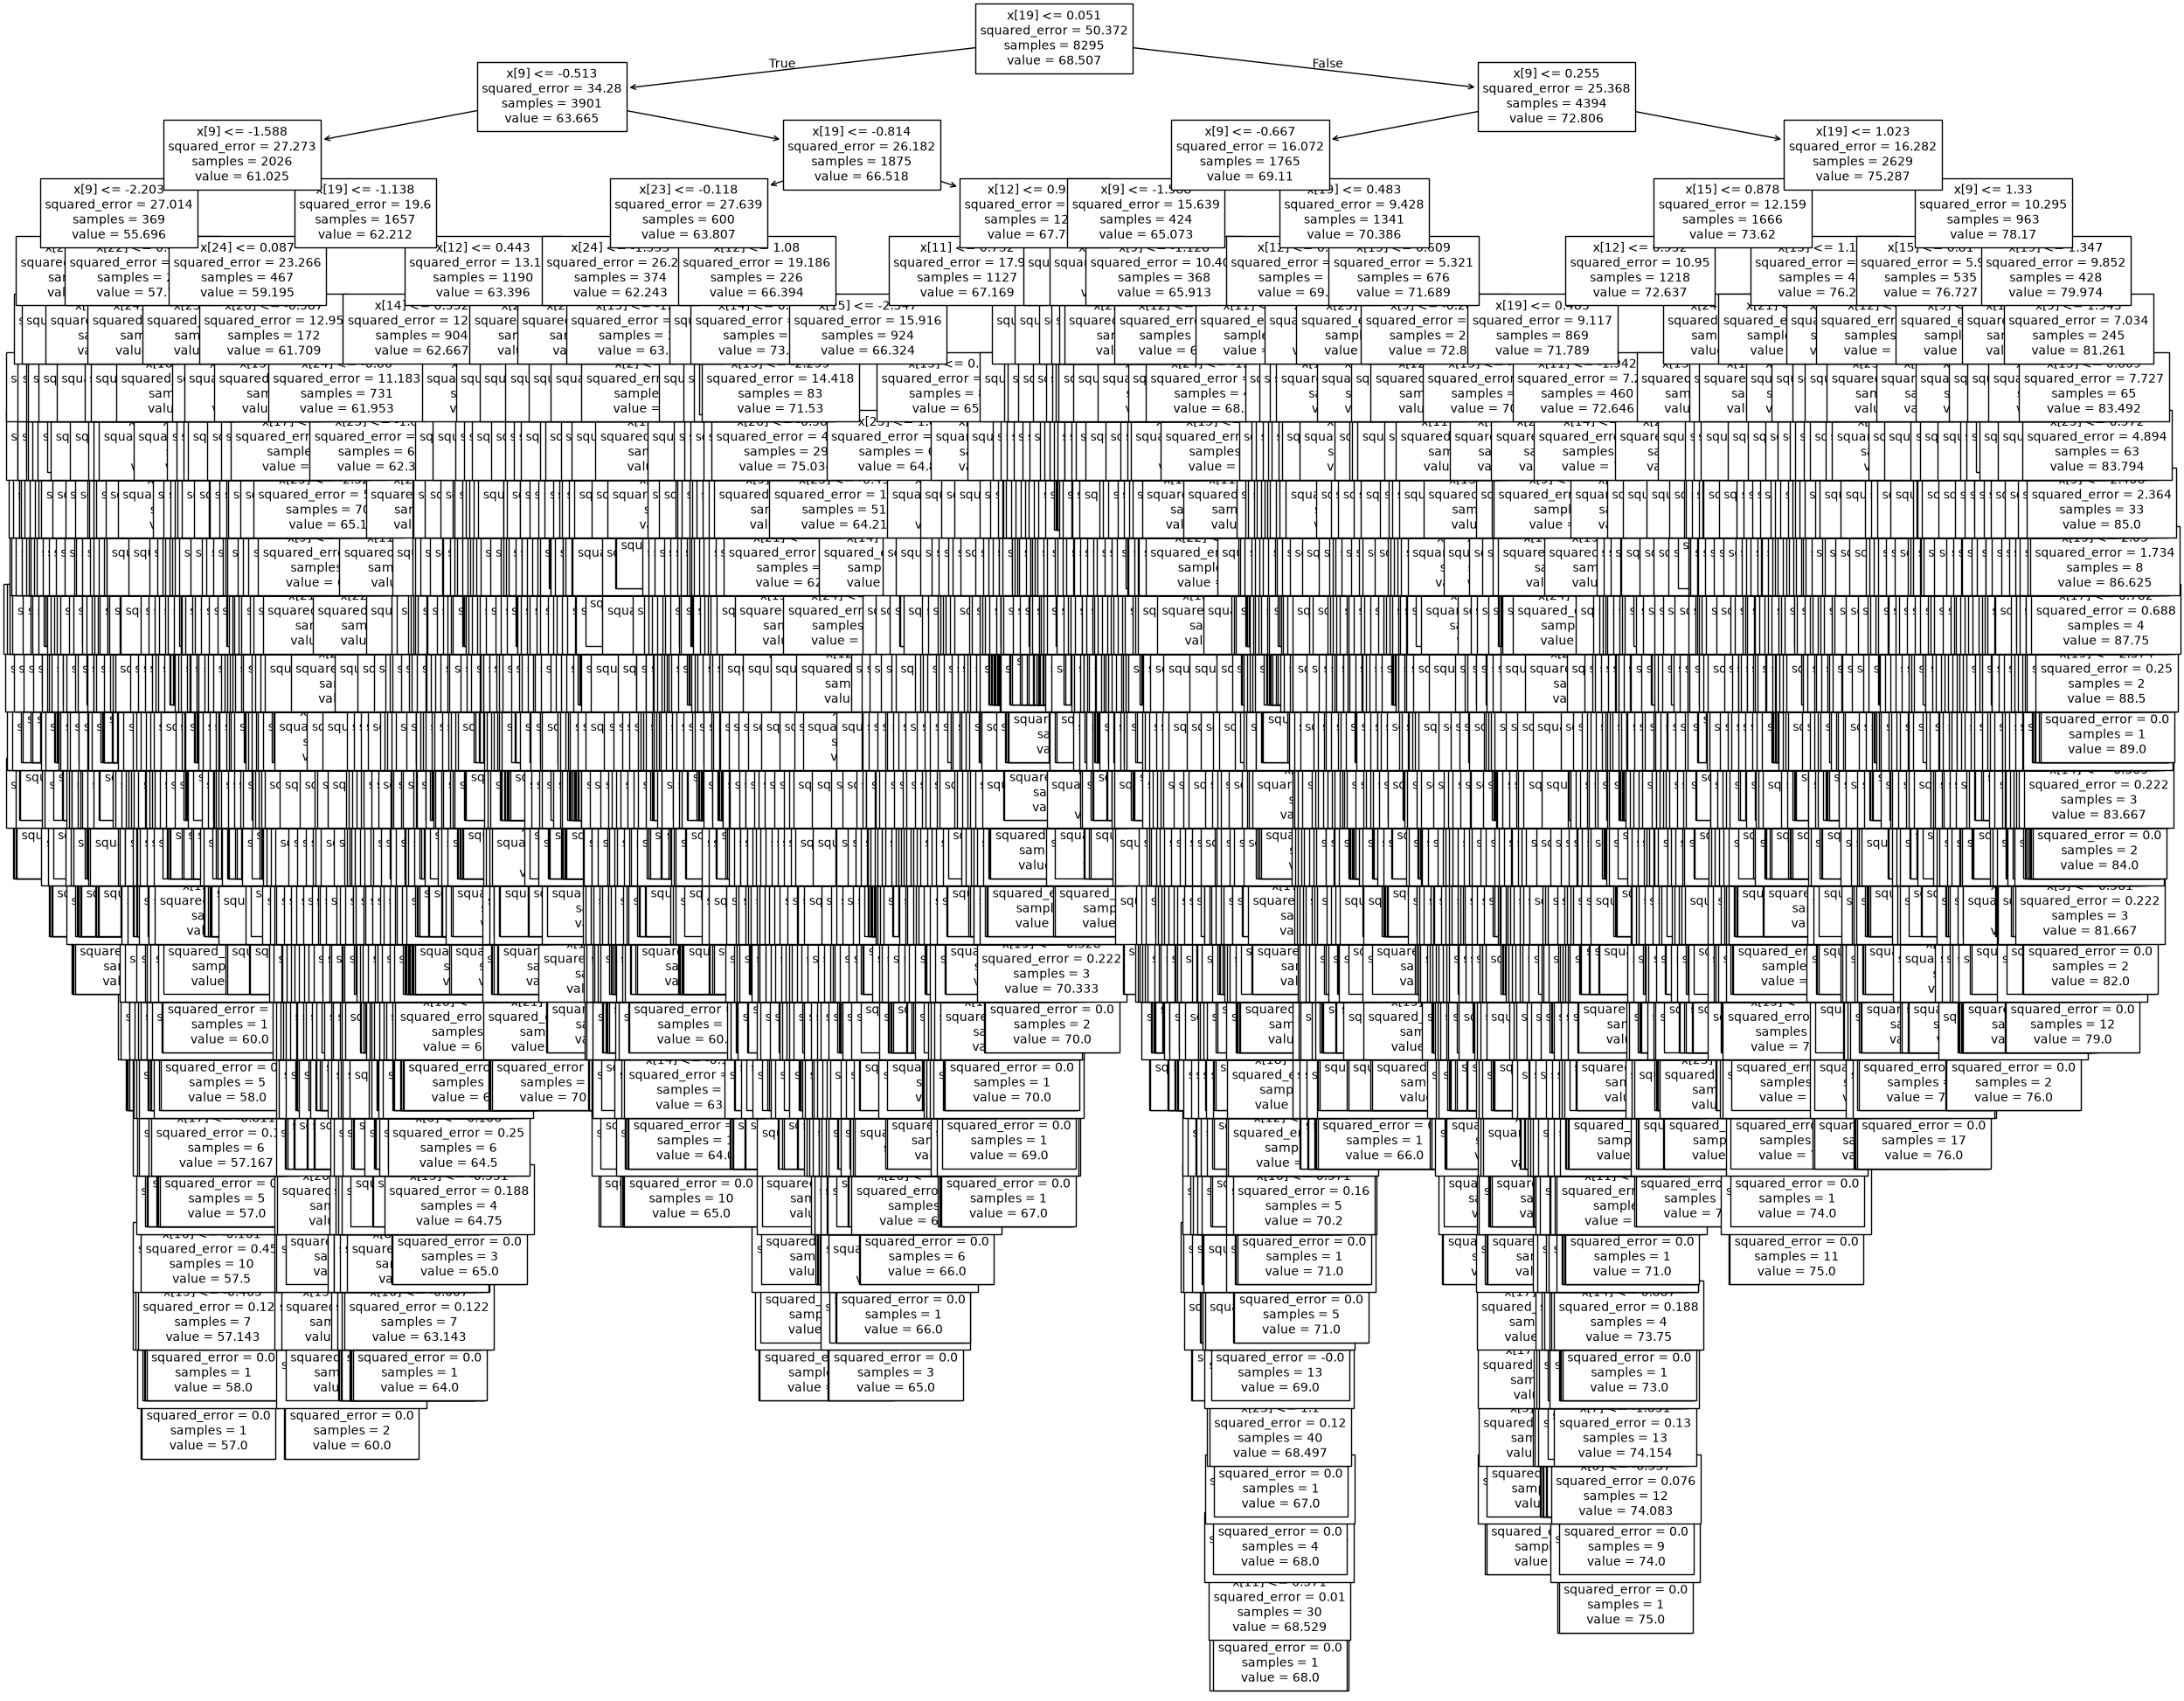

In [41]:
# Visualize the Decision Tree
# Visualizar el Árbol de Decisión

plt.figure(figsize = (30,25))
tree.plot_tree(dt,fontsize = 10)
plt.show()

In [42]:
#Feature Importances según las columnas / Feature Importances according to the columns
Xfi = pd.DataFrame(X)
Columnas_X = list(Xfi.columns.values)
fn = Columnas_X
FI = dt.feature_importances_

In [43]:
for feature,importance in zip(fn, FI):
  print('feature: {}, importance: {:.4f}'.format(feature,importance))


feature: 0, importance: 0.0005
feature: 1, importance: 0.0002
feature: 2, importance: 0.0014
feature: 3, importance: 0.0008
feature: 4, importance: 0.0002
feature: 5, importance: 0.0005
feature: 6, importance: 0.0014
feature: 7, importance: 0.0008
feature: 8, importance: 0.0030
feature: 9, importance: 0.2474
feature: 10, importance: 0.0005
feature: 11, importance: 0.0233
feature: 12, importance: 0.0348
feature: 13, importance: 0.0111
feature: 14, importance: 0.0173
feature: 15, importance: 0.0481
feature: 16, importance: 0.0071
feature: 17, importance: 0.0062
feature: 18, importance: 0.0068
feature: 19, importance: 0.4879
feature: 20, importance: 0.0040
feature: 21, importance: 0.0185
feature: 22, importance: 0.0120
feature: 23, importance: 0.0181
feature: 24, importance: 0.0272
feature: 25, importance: 0.0132
feature: 26, importance: 0.0076


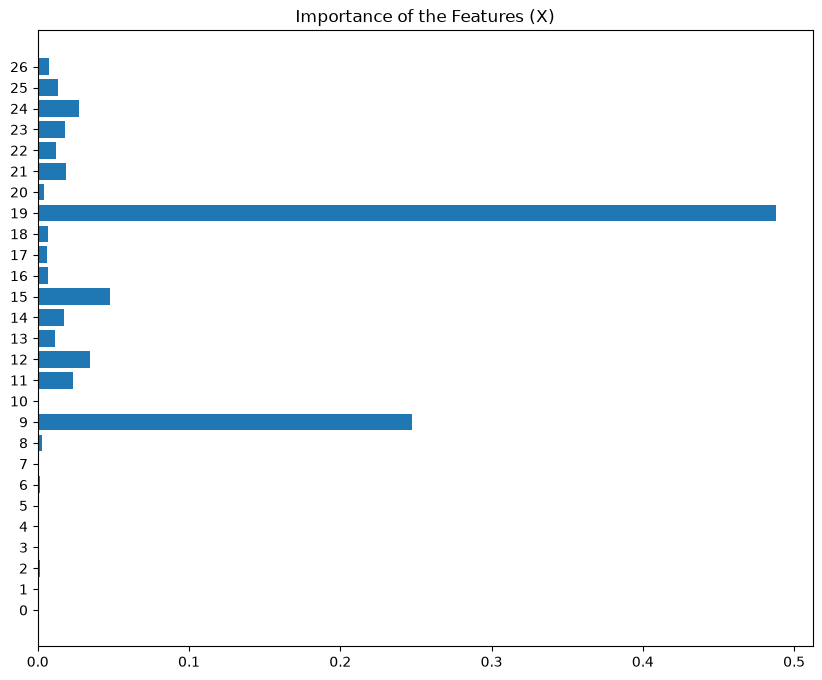

In [44]:
plt.figure(figsize=(10,8))
plt.barh(fn,FI)
plt.title("Importance of the Features (X)")
plt.yticks(range(0, 27, 1))
plt.show()

Most important variables: 19, 9, 15.

19 = Agility

9 = Weight

15 = Ball control

---

Variables más importantes: 19, 9, 15.

19 = Agilidad

9 = Peso

15 = Control de balón

### The Best Model

---

### El Mejor Modelo

#### Metrics

---

#### Métricas

In [45]:
# Based on the R2 score, the best model is KNN.
# Según la métrica R2, el mejor modelo es KNN.


print(' R2  KNN: ', r2_knn, '\n', 'R2  Decision Tree: ', r2_DT , '\n','R2  Linear Regression: ', r2_lr  , '\n','R2  Support Vector Regression: ' , r2_MSV)

 R2  KNN:  0.9021676105899709 
 R2  Decision Tree:  0.779761437684537 
 R2  Linear Regression:  0.7803626188248693 
 R2  Support Vector Regression:  0.779761437684537


In [46]:
# Model KNN predictions
# Predicciones del modelo KNN
y_pred_knn[:9].T

array([[68.6       , 64.4       , 74.        , 61.        , 72.6       ,
        68.30939116, 79.4       , 65.4       , 62.4       ]])

In [47]:
# The real target values from the dataset
# Los valores reales del objetivo en el dataset
y_test[:9].T

array([[67., 62., 77., 63., 74., 73., 81., 65., 61.]])

In [48]:
# An example of input values
# Un ejemplo de valores de entrada

Xsample = pd.DataFrame(X_test)
Xsample= Xsample.sample().values
Xsample

array([[-0.38833576, -0.34972978,  0.56198863, -0.58556374, -0.19504563,
         0.64218043, -0.99590932, -1.82900324, -1.69237372, -1.20439511,
         0.53930481, -2.06202587, -2.13714752, -2.61911789, -2.73413638,
        -3.05028151, -2.74316487, -3.09855231, -1.91032166, -0.11144896,
        -1.43692162, -2.48787599, -1.08599482, -3.04861412, -0.03160264,
        -1.72627737, -2.23186813]])

In [49]:
# Prediction using the previous input values / Predicción con los valores de entrada anteriores

ynueva = knn.predict(Xsample)
ynueva

array([[62.8]])

Model performance can be improved by focusing on the most important features, such as Agility, Weight, and Ball Control, as identified by the Decision Tree.

---

El desempeño del modelo puede mejorarse enfocándose en las características más importantes, como Agilidad, Peso y Control de Balón, identificadas por el Árbol de Decisión.